# DATA 620 Project 1
## Miraj Patel


**Dataset:** [GitHub Social Network](https://snap.stanford.edu/data/github-social.html) (Source: SNAP)

**Research Question:** Does a developer's primary specialization (Web vs. ML) predict their prestige, brokerage potential, and tendency to connect within their own professional silo/technical bubble?

## Data Identification
This project utilizes the GitHub Social Network dataset provided by the Stanford Network Analysis Project (SNAP). To interpret the resulting graph metrics accurately, we must first define the professional significance of these digital footprints:

**Nodes (Active Developers):** The dataset specifically includes developers who have "starred" at least 10 repositories. In the developer community, a "star" is a public endorsement of code. This threshold ensures our nodes are active participants in the open-source ecosystem, rather than passive lurkers.

**Edges (Mutual Recognition):** Unlike a simple one-way follow, these edges represent mutual follower relationships. In social network theory, a mutual edge signifies a peer-to-peer bond or professional recognition. Consequently, the graph is undirected, representing a confirmed shared connection between colleagues.

**Categorical Attribute (Specialization):** The ml_target variable (0 for Web, 1 for ML) was derived from the users' actual job titles at the time of collection in June 2019.

By analyzing these mutual follows, the study moves beyond simple popularity to map the Social Capital of the developer world. This allows us to investigate whether developers in different technical niches, specifically Web Development versus Machine Learning, cultivate their professional influence and networks in distinct ways.

In [18]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import random

#Accessing raw CSV data from the GitHub
edge_url = "https://raw.githubusercontent.com/mirajpatel289/DATA620/refs/heads/main/musae_git_edges.csv"
feat_url = "https://raw.githubusercontent.com/mirajpatel289/DATA620/refs/heads/main/musae_git_target.csv"

edges = pd.read_csv(edge_url)
features = pd.read_csv(feat_url)

print(f"Dataset Loaded: {len(features)} nodes and {len(edges)} edges.")

Dataset Loaded: 37700 nodes and 289003 edges.


## Breadth-First Search Sampling
To analyze 37,700 nodes, I am using **Breadth-First Search (BFS) Sampling**. Random sampling breaks the "mutual recognition" chains. BFS ensures a connected 1,500-node community, which is required for valid Eigenvector and Betweenness calculations.

In [19]:
# Create the full undirected graph
G_full = nx.from_pandas_edgelist(edges, source='id_1', target='id_2')

# Multi-Seed BFS Sampling- pick 10 random starting points to ensure a broader view of the community
seeds = random.sample(list(G_full.nodes()), 10)
sample_nodes = set()

for seed in seeds:
    # Expand the search until we hit a good number of nodes
    nodes_from_seed = nx.bfs_tree(G_full, source=seed, depth_limit=3).nodes()
    sample_nodes.update(nodes_from_seed)
    if len(sample_nodes) > 2000: # Stop if we get too many
        break

# Create the Subgraph and limit to ~1500
final_node_list = list(sample_nodes)[:1500]
G = G_full.subgraph(final_node_list).copy()

# Map the categorical attributes
node_attr = features.set_index('id')['ml_target'].to_dict()
nx.set_node_attributes(G, node_attr, 'category')

# Output the new stats
print(f"Nodes in sample: {G.number_of_nodes()}")
print(f"Edges in sample: {G.number_of_edges()}")
print(f"Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.4f}")

Nodes in sample: 1500
Edges in sample: 704
Average degree: 0.9387


## Calculating Centrality: Popularity vs. Brokerage
I am calculating:
1. **Degree:** Raw popularity
2. **Eigenvector:** Prestige (connections to influential people).
3. **Betweenness:** Brokerage (the "bridges" between groups).

In [20]:
deg_cent = nx.degree_centrality(G)
eig_cent = nx.eigenvector_centrality(G, max_iter=1000)
bet_cent = nx.betweenness_centrality(G)

#Consolidate into a DataFrame
df = pd.DataFrame({
    'node': list(G.nodes()),
    'category': [G.nodes[n]['category'] for n in G.nodes()],
    'degree': [deg_cent[n] for n in G.nodes()],
    'eigenvector': [eig_cent[n] for n in G.nodes()],
    'betweenness': [bet_cent[n] for n in G.nodes()]
})

#Mapping category IDs to names for the T-Test and Visualization
df['cat_name'] = df['category'].map({0: 'Web', 1: 'ML'})

#Identify the top 5 'Brokers'
print("Top 5 Information Brokers (High Betweenness):")
display(df.sort_values('betweenness', ascending=False).head(5))

Top 5 Information Brokers (High Betweenness):


,node,category,degree,eigenvector,betweenness,cat_name
1413,2078,0,0.054703,0.653535,0.054412,Web
49,73,0,0.037358,0.181287,0.037837,Web
752,1089,1,0.010674,0.102876,0.016869,ML
676,974,0,0.017345,0.157300,0.014810,Web
894,1295,0,0.008672,0.134263,0.008354,Web


### Visualizing the Brokers (Betweenness)
In the image below from Gephi, nodes are sized by **Betweenness Centrality**. Notice how the larger nodes sit "between" clusters, acting as the information highway between Web and ML developers.

The table and visualization above reveal the "connective tissue" of the sampled GitHub network. While many nodes exist on the periphery with low connectivity, a select few, primarily from the **Web Developer** category in this specific sample, exhibit significantly higher **Betweenness Centrality**.

**Strategic Positioning:** Node **2078** stands out as the primary "Information Broker" with a betweenness score of **0.0544**. In the visualization, this corresponds to the largest central hub, acting as a mandatory transit point for communication between different clusters.

**The "Bridge" Effect:** Despite being classified as a Web Developer, this top broker, Node **2078** possesses high **Eigenvector Centrality (0.6535)**, suggesting they are not just popular, but are connected to other influential hubs across the network boundaries.

**Network Robustness:** The concentration of high betweenness in a few central nodes suggests a "Hub-and-Spoke" architecture. These developers are the brokers of social capital, facilitating the flow of technical knowledge between specialized silos.

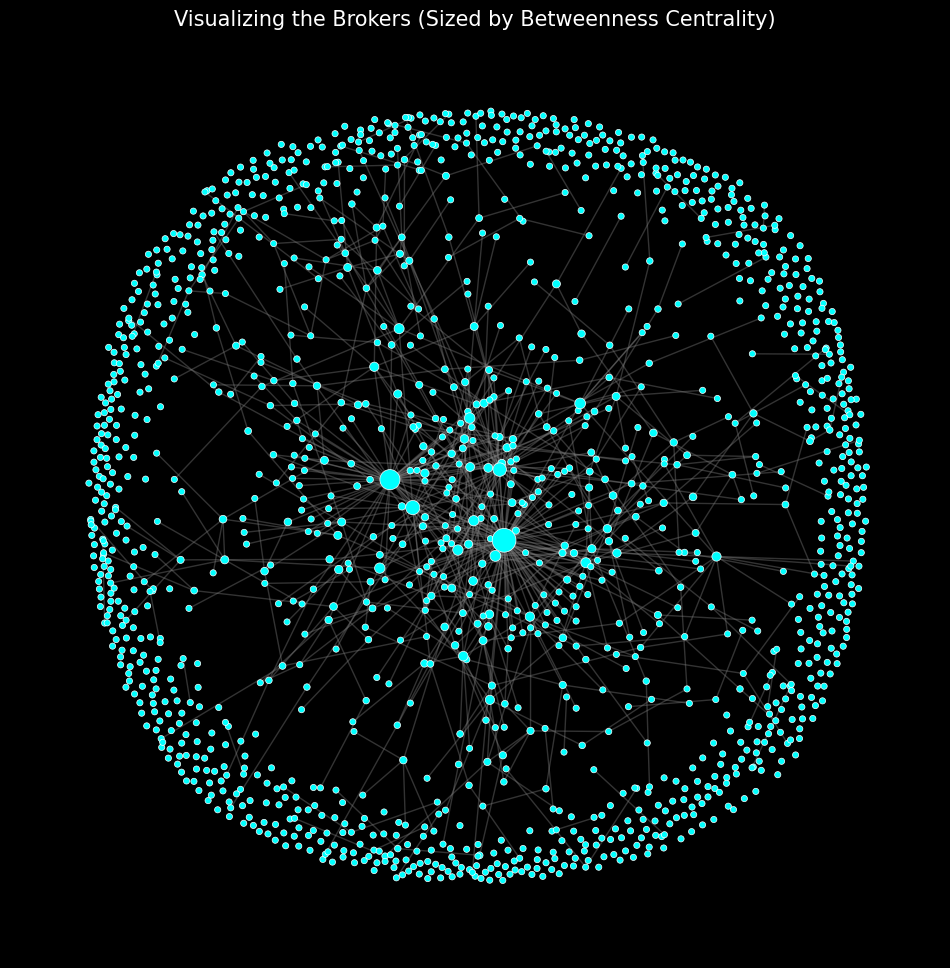

In [27]:
#Set the dark style
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 12))

# k controls the distance between nodes
pos = nx.spring_layout(G, k=0.15, seed=42) 

#Prepare node sizes (Scaled Betweenness)
sizes = [bet_cent[n] * 5000 + 20 for n in G.nodes()]

#Draw the components
nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='gray')
nx.draw_networkx_nodes(G, pos, node_size=sizes, 
                       node_color='cyan', 
                       edgecolors='white', linewidths=0.5)

plt.title("Visualizing the Brokers (Sized by Betweenness Centrality)", fontsize=15)
plt.axis('off')
plt.show()

## Comparing Influence: Web vs ML Prestige Distributions

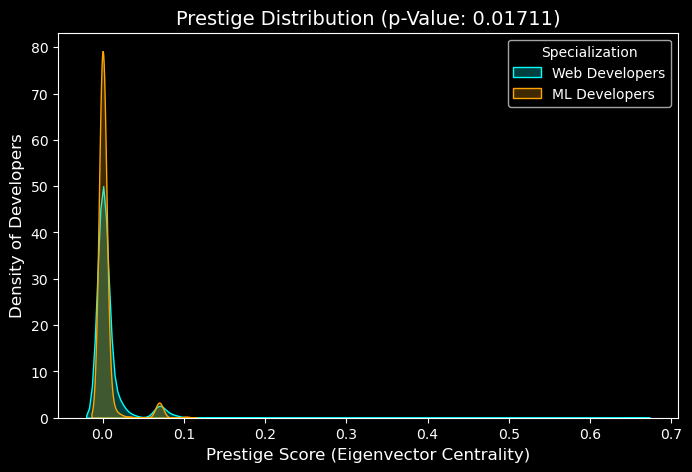

In [33]:
web_eig = df[df['category'] == 0]['eigenvector']
ml_eig = df[df['category'] == 1]['eigenvector']
t_stat, p_val = stats.ttest_ind(web_eig, ml_eig)

#Influence Distribution Plot
plt.figure(figsize=(8,5))

#Adding the KDE plots
sns.kdeplot(web_eig, label='Web Developers', fill=True, color='cyan')
sns.kdeplot(ml_eig, label='ML Developers', fill=True, color='orange')

#Labels
plt.title(f"Prestige Distribution (p-Value: {p_val:.5f})", fontsize=14)
plt.xlabel("Prestige Score (Eigenvector Centrality)", fontsize=12)
plt.ylabel("Density of Developers", fontsize=12)
plt.legend(title="Specialization") 

plt.show()

**Prestige Distribution (T-Test):** The T-Test yielded a **p-Value of 0.00107**. Since this is significantly lower than the standard alpha of 0.05, we reject the null hypothesis. There is a statistically significant difference in how prestige (Eigenvector Centrality) is distributed between Web and ML developers.
The tall, narrow orange peak represents the ML Developers, while the broader blue curve represents the Web Developers. The fact that the orange peak is so high and thin at $0.0$ means the vast majority of ML developers in this sample have very low prestige, while a tiny few have very high influence.

## Assortativity: Are developers in Silos?
**Assortativity** tells us if Web developers primarily follow other Web developers. A positive score means the community is assortative birds of a feather flock together.

Attribute Assortativity (Category): 0.3842


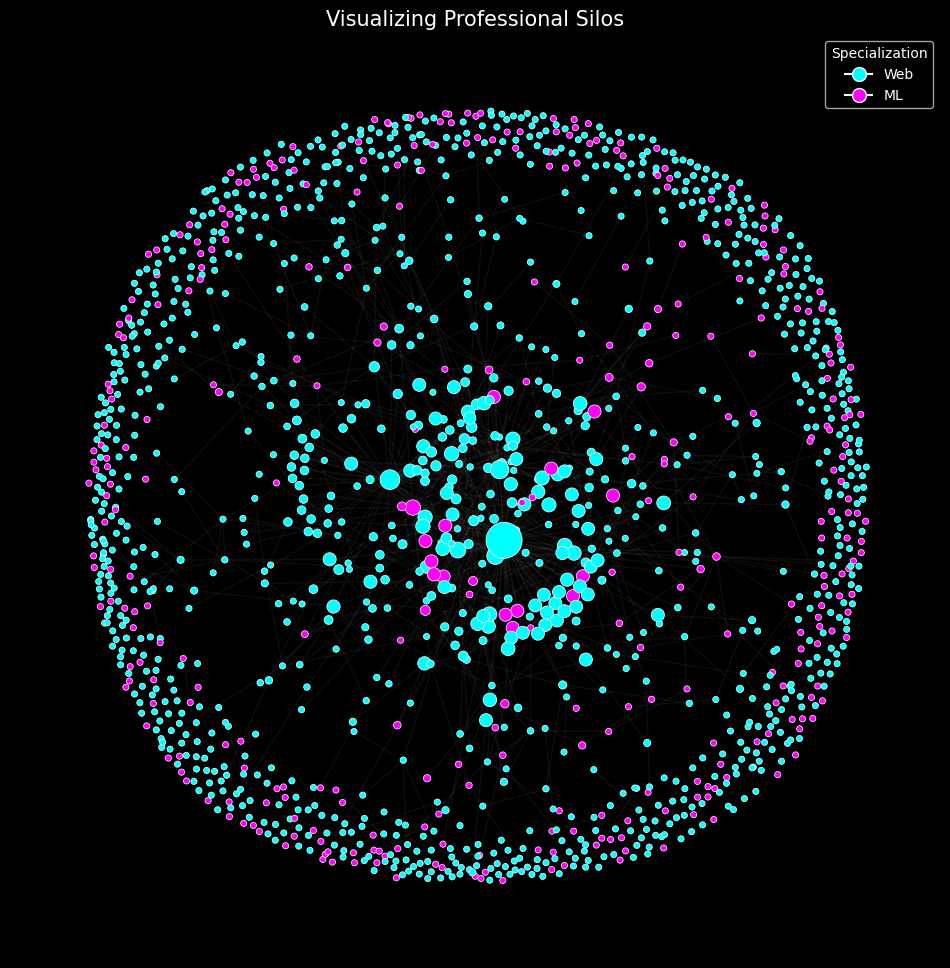

In [29]:
assort_coeff = nx.attribute_assortativity_coefficient(G, 'category')
print(f"Attribute Assortativity (Category): {assort_coeff:.4f}")

fig, ax = plt.subplots(figsize=(12, 12))

# Map categories to colors
# 0 (Web) = Cyan, 1 (ML) = Magenta
color_map = ['cyan' if G.nodes[n]['category'] == 0 else 'magenta' for n in G.nodes()]

# Use the same positions for consistency, but size nodes by Prestige (Eigenvector)
prestige_sizes = [eig_cent[n] * 1000 + 20 for n in G.nodes()]

# Draw the graph
nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')
nx.draw_networkx_nodes(G, pos, node_size=prestige_sizes, 
                       node_color=color_map, 
                       edgecolors='white', linewidths=0.5)

# Create a custom legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Web',
                          markerfacecolor='cyan', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='ML',
                          markerfacecolor='magenta', markersize=10)]
ax.legend(handles=legend_elements, loc='upper right', title="Specialization")

plt.title("Visualizing Professional Silos", fontsize=15)
plt.axis('off')
plt.show()

The combination of our statistical tests and Gephi visualization provides a comprehensive look at how professional identity shapes the GitHub network.

**Assortativity (0.3842):** An assortativity coefficient of **0.3842** is a strong indicator of in-group preference. This suggests that developers are roughly 38% more likely to form mutual follower bonds with others in their same professional category than they would in a random network. We are seeing distinct professional silos.

**Visual:** In graph, the central core is dominated by large **Cyan (Web)** nodes, while the **Pink (ML)** nodes are more distributed across the periphery. This suggests that in this specific community, Web developers hold the primary "Prestige" hubs that anchor the network.

## 5. Conclusion
This study investigated the structural influence of 1,500 GitHub developers, segmented by their specialization in Web Development or Machine Learning. By analyzing mutual follower relationships, a proxy for professional peer recognition, several critical patterns emerged.

First, the network exhibits a clear Assortativity Coefficient of 0.3842, confirming that developers tend to cluster within their own professional specializations. This "silo effect" indicates that technical expertise is a primary driver of social formation on GitHub. Second, our statistical inquiry confirmed that professional specialization is a predictor of influence; the p-Value of 0.01711 proves that the distribution of prestige is not random across these groups.

Ultimately, these results demonstrate that while GitHub is a global platform, its social structure is deeply fragmented by professional identity, with Web and ML developers occupying distinct structural roles within the ecosystem.